# Defect Localization and Explainability

**Purpose.** Show how anomaly evidence becomes a heatmap, binary defect mask, geometric description, and readable explanation.

**Expected result.** A real MVTec image compared against its annotation mask with IoU, Dice, coverage, area ratio, center, and region labels.

**Platform connection.** The frontend displays the heatmap and explanation; the severity module consumes area and critical-zone overlap.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from dataclasses import replace

from ml.inference import baseline_anomaly_prediction, compute_defect_geometry
from ml.heatmap import localization_metrics, mask_overlay, overlay_heatmap
from ml.predict import build_inference_config

CATEGORY = "bottle"
DEFECT = "broken_large"
image_path = first_test_image(CATEGORY, DEFECT)
ground_truth_path = mask_path_for(CATEGORY, DEFECT, image_path)
if ground_truth_path is None:
    raise FileNotFoundError("The expected ground-truth mask is unavailable.")

config = replace(
    build_inference_config(CATEGORY),
    use_padim_inference=False,
    use_openvino_inference=False,
    openvino_path=None,
    openvino_calibrator_path=None,
)
image_bgr = cv2.imread(str(image_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
ground_truth = cv2.imread(str(ground_truth_path), cv2.IMREAD_GRAYSCALE) > 0
anomaly = baseline_anomaly_prediction(image_path, image_bgr, config)
predicted_mask = anomaly["pred_mask"]
metrics = localization_metrics(ground_truth, predicted_mask)
geometry = compute_defect_geometry(predicted_mask, DEFECT, critical_zones=("center", "edge"))

display(pd.DataFrame([metrics]))
display(pd.DataFrame([geometry]))

,iou,dice,ground_truth_coverage,ground_truth_area_ratio,predicted_area_ratio
0,0.2977,0.4588,0.3073,0.1089,0.037


,area_ratio,defect_center_x_ratio,defect_center_y_ratio,is_critical_location,detected_regions,critical_zones
0,0.036835,0.664927,0.685391,True,"[center, edge, top, bottom, left, right]","[center, edge]"


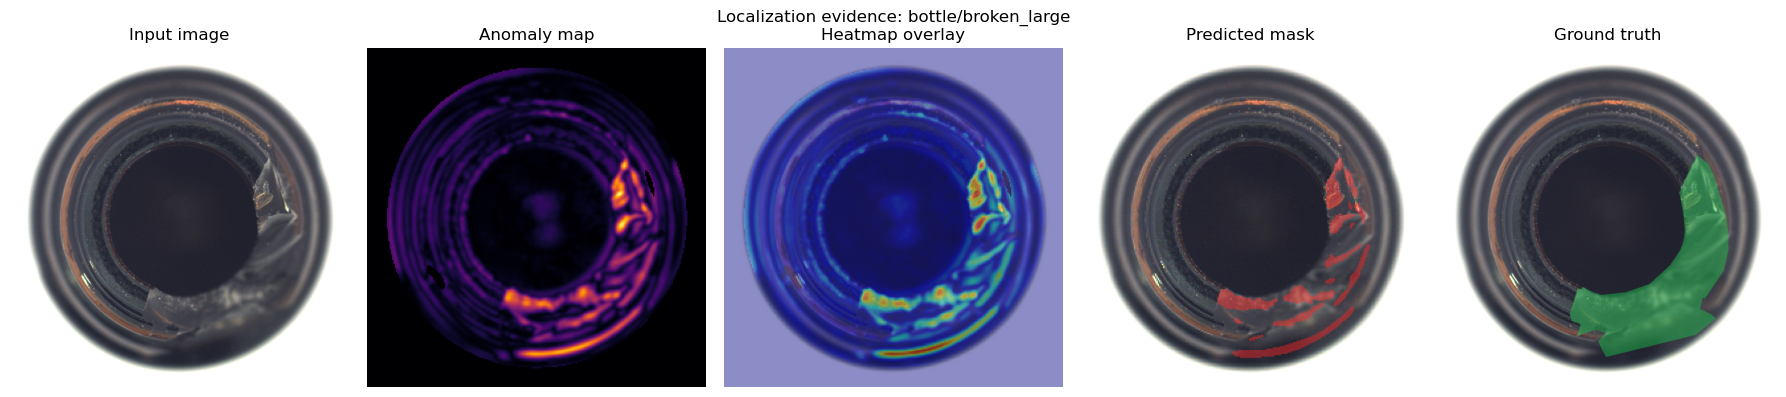

In [3]:
heatmap = overlay_heatmap(image_rgb, anomaly["anomaly_map"])
predicted_overlay = mask_overlay(
    cv2.resize(image_rgb, (predicted_mask.shape[1], predicted_mask.shape[0])),
    predicted_mask,
    color=(255, 40, 40),
)
ground_truth_overlay = mask_overlay(image_rgb, ground_truth, color=(30, 200, 80))

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
panels = [
    ("Input image", image_rgb, None),
    ("Anomaly map", anomaly["anomaly_map"], "inferno"),
    ("Heatmap overlay", heatmap, None),
    ("Predicted mask", predicted_overlay, None),
    ("Ground truth", ground_truth_overlay, None),
]
for axis, (title, value, color_map) in zip(axes, panels, strict=True):
    axis.imshow(value, cmap=color_map)
    axis.set_title(title)
    axis.axis("off")
plt.suptitle(f"Localization evidence: {CATEGORY}/{DEFECT}")
plt.tight_layout()
plt.show()

In [4]:
from ml.model_registry import SUPPORTED_CATEGORIES, category_model_spec

pixel_rows = []
for category in SUPPORTED_CATEGORIES:
    metadata = json.loads(category_model_spec(category).metadata_path.read_text(encoding="utf-8"))
    stored = metadata.get("metrics", {})
    stored = stored[0] if isinstance(stored, list) and stored else stored
    pixel_rows.append(
        {
            "category": category,
            "selected_detector": metadata.get("model_name"),
            "pixel_AUROC": stored.get("pixel_AUROC"),
            "pixel_F1": stored.get("pixel_F1Score"),
        }
    )
pixel_df = pd.DataFrame(pixel_rows)
display(pixel_df.style.format({"pixel_AUROC": "{:.4f}", "pixel_F1": "{:.4f}"}, na_rep="n/a"))

,category,selected_detector,pixel_AUROC,pixel_F1
0,bottle,padim,0.9820,0.7141
1,cable,patchcore,0.9815,0.6147
2,capsule,padim,0.9848,0.4267
3,carpet,padim,0.9896,0.5656
4,grid,padim,0.9699,0.4019
5,hazelnut,patchcore,0.9881,0.6424
6,leather,padim,0.9897,0.3675
7,metal_nut,padim,0.9679,0.7619
8,pill,padim,0.9588,0.5451
9,screw,patchcore,0.9918,0.3717


## What the localization values mean

- **IoU:** intersection divided by union of predicted and annotated defect pixels.
- **Dice:** overlap score that weights the shared area twice.
- **Ground-truth coverage:** fraction of the annotated defect recovered by the prediction.
- **Area ratio:** fraction of the inspected image occupied by the cleaned defect mask.
- **Detected regions:** coarse spatial labels such as center, edge, top, or left.

This project performs anomaly localization, not bounding-box object detection. A separate YOLO model is unnecessary for the current MVTec requirement because the needed output is the defective region, represented by an anomaly map and mask.

## What this demonstrates

Localization is both visual and measurable. The pipeline preserves the anomaly map for inspection, creates a stable mask for geometry, compares it with MVTec masks during evaluation, and translates spatial evidence into fields that the severity and reporting modules can use.